In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## <포아송 회귀>

Q. 광고비(ad_spend), 매장 크기(store_size), 주말 여부(is_weekend)로 하루 방문자 수를 예측하는 회귀모델을 적합하시오.

- ad_spend : 광고비 (연속형, 1~10 사이)

- store_size : 매장 크기(평수, 30~100 사이)

- is_weekend : 주말 여부 (0=평일, 1=주말)

- visitors : 하루 방문자 수

- 종속변수: visitors

- 독립변수: ad_spend, store_size, is_weekend

주어진 데이터를 이용하여 포아송 회귀 모형을 적합하라.

1. 각 독립변수가 방문자 수에 미치는 영향을 해석하라.

2. 광고비(ad_spend)가 증가할수록 방문자 수가 어떻게 변하는가?

3. 매장 크기(store_size)가 커질수록 방문자 수에 어떤 영향이 있는가?

4. 주말(is_weekend)일 때 방문자 수가 평일 대비 어떻게 달라지는가?

5. 포아송 회귀 모형이 적절한지, 과산포 여부를 평균과 분산을 비교하여 진단하라.

In [ ]:
file_path = "./data/poisson_regression.csv"

df = pd.read_csv(file_path)
df

,ad_spend,store_size,is_weekend,visitors
0,7.268223,67.984515,0,5
1,3.575254,34.674211,0,7
2,3.041663,75.735541,0,6
3,5.961833,99.726043,0,5
4,7.475221,83.857814,0,5
...,...,...,...,...
195,6.723103,55.229660,0,5
196,1.289781,44.745684,1,5
197,7.703026,59.484004,1,3
198,5.256217,45.262481,0,6


In [ ]:
### 원본 데이터
df

,ad_spend,store_size,is_weekend,visitors
0,7.268223,67.984515,0,5
1,3.575254,34.674211,0,7
2,3.041663,75.735541,0,6
3,5.961833,99.726043,0,5
4,7.475221,83.857814,0,5
...,...,...,...,...
195,6.723103,55.229660,0,5
196,1.289781,44.745684,1,5
197,7.703026,59.484004,1,3
198,5.256217,45.262481,0,6


In [ ]:
### 종속변수 확인
df["visitors"].unique()

array([ 5,  7,  6,  3, 10,  4, 13,  9,  8,  2, 11,  1,  0, 14],
      dtype=int64)

In [ ]:
print("""
종속변수가 빈도(counts) 이므로 포아송 분포 or 음이항 분포를 따를 것이다.
""")


종속변수가 빈도(counts) 이므로 포아송 분포 or 음이항 분포를 따를 것이다.



In [ ]:
### 종속변수 평균, 분산 비교

m = df["visitors"].mean()
v = df["visitors"].var(ddof=1)

print(f"종속변수의 평균 : {m}")
print(f"종속변수의 분산 : {v}")

종속변수의 평균 : 5.53
종속변수의 분산 : 6.551859296482413


In [ ]:
print("""
표본 평균과 표본 분산이 비슷하므로 포아송 분포를 따른다.
""")


표본 평균과 표본 분산이 비슷하므로 포아송 분포를 따른다.



In [ ]:
### 데이터 분할
train = df.iloc[:160,:]
test = df.iloc[160:,:]

In [ ]:
### 포아송 회귀
from statsmodels.api import GLM, families

formula = "visitors ~ ad_spend + store_size + C(is_weekend)"

model = GLM.from_formula(formula, data=train, family=families.Poisson()).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               visitors   No. Observations:                  160
Model:                            GLM   Df Residuals:                      156
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -356.60
Date:                Sun, 24 Aug 2025   Deviance:                       162.60
Time:                        15:57:18   Pearson chi2:                     154.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1777
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.9846      0.146      6.749      0.000       0.699       1.271
C(is_weekend)[T.1]     0.2170      0.069      3.133      0.002       0.081       0.353
ad_spend               0.0436      0.015      2.945      0.003       0.015       0.073
store_size             0.0053      0.002      3.290      0.001       0.002       0.008
======================================================================================
"""

In [ ]:
### 로그-우도

model.llf

-356.6039141146894

In [ ]:
### McFadden’s Pseudo R²(모델 설명력)
p_r2 = 1-(model.llf / model.llnull)
p_r2

0.04205455948886894

In [ ]:
### 잔차 이탈도

model.deviance

162.595758026165

In [ ]:
### 우도비 검정
from scipy.stats import chi2

# H0 : 모든 회귀계수가 0이다.(=모델이 통계적으로 유의하지 않다.)
# H1 : 적어도 하나의 회귀계수는 0이 아니다.(=모델이 통계적으로 유의하다.)

# 우도비 검정통계량
s = model.null_deviance - model.deviance

# 우도비 검정통계량의 p-value
rv = chi2(loc=0, scale=1, df=model.df_model)

p = 1-rv.cdf(s)

print(f"우도비 검정통계량 : {s}")
print(f"우도비 검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

우도비 검정통계량 : 31.310385510260318
우도비 검정통계량의 p-value : 7.31274471088561e-07
귀무가설 기각


In [ ]:
### 회귀계수의 통계적 유의성 검정

model.pvalues[1:]

C(is_weekend)[T.1]    0.001733
ad_spend              0.003229
store_size            0.001003
dtype: float64

In [ ]:
print("""
유의수준 5%하에서 회귀계수가 통계적으로 유의하다.
""")


유의수준 5%하에서 회귀계수가 통계적으로 유의하다.



In [ ]:
### 발생률 비율(IRR)

np.exp(model.params[1:])

C(is_weekend)[T.1]    1.242308
ad_spend              1.044601
store_size            1.005274
dtype: float64

In [ ]:
### 발생률 비율(IRR) 증가율

(np.exp(model.params[1:]) - 1)*100

C(is_weekend)[T.1]    24.230835
ad_spend               4.460087
store_size             0.527381
dtype: float64

In [ ]:
print("""
주말일때 방문자 수가 약 1.24배 증가한다.
광고비를 한단위 증가할때 방문자 수가 약 1.044배 증가한다.
매장크기를 한단위 증가할때 방문자 수가 약 1.005배 증가한다.
""")


주말일때 방문자 수가 약 1.24배 증가한다.
광고비를 한단위 증가할때 방문자 수가 약 1.044배 증가한다.
매장크기를 한단위 증가할때 방문자 수가 약 1.005배 증가한다.



In [ ]:
## 예측
pred = model.predict(test)
pred = pred.round(0).astype("int")
pred.head(5)

160    6
161    5
162    7
163    4
164    6
dtype: int32

In [ ]:
### 평가
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test["visitors"], pred)
print(f"포아송 회귀모델 MAE : {mae}")

포아송 회귀모델 MAE : 1.975


## <음이항 회귀>

Q. 병원 응급실의 일일 환자 방문 횟수 예측모델을 적합하시오.

- hospital_size: 병원 규모 (1-5단계)
- medical_staff: 응급실 의료진 수
- weather_severity: 날씨 상태 (맑음/보통/악천후)
- season: 계절 (봄/여름/가을/겨울)
- nearby_population: 병원 인근 인구수
- traffic_index: 교통사고 위험지수
- is_weekend: 주말/공휴일 여부
- daily_visits: 일일 환자 방문 횟수 [종속변수]

In [ ]:
file_path = "./data/hospital_emergency.csv"

df = pd.read_csv(file_path)
df

,hospital_size,medical_staff,weather_severity,season,nearby_population,traffic_index,is_weekend,daily_visits
0,4,6,악천후,봄,4636,36,0,7
1,5,10,보통,가을,4275,10,1,20
2,3,10,악천후,봄,3008,99,1,91
3,5,15,악천후,가을,3279,76,0,298
4,5,19,보통,봄,1424,2,0,99
...,...,...,...,...,...,...,...,...
195,3,12,악천후,겨울,724,14,0,78
196,3,6,보통,여름,4708,20,1,69
197,1,20,맑음,겨울,2548,46,1,115
198,5,19,맑음,겨울,4915,72,1,5


In [ ]:
### 원본 데이터
df

,hospital_size,medical_staff,weather_severity,season,nearby_population,traffic_index,is_weekend,daily_visits
0,4,6,악천후,봄,4636,36,0,7
1,5,10,보통,가을,4275,10,1,20
2,3,10,악천후,봄,3008,99,1,91
3,5,15,악천후,가을,3279,76,0,298
4,5,19,보통,봄,1424,2,0,99
...,...,...,...,...,...,...,...,...
195,3,12,악천후,겨울,724,14,0,78
196,3,6,보통,여름,4708,20,1,69
197,1,20,맑음,겨울,2548,46,1,115
198,5,19,맑음,겨울,4915,72,1,5


In [ ]:
### 종속 변수
df["daily_visits"].unique()

array([  7,  20,  91, 298,  99, 370,   1,  76,  28,  71,  12,  81,   6,
        19, 375, 246, 114,  31, 105, 150, 281,   0,  72, 327, 149, 241,
        39,   2, 168, 377,  14, 170, 156,  22,   3, 247,   4,  10,  70,
       277, 244, 108, 325, 191,  25,  74,  63, 422, 145,  73,  55,  26,
        44,  53, 139, 292, 117, 455,  90, 273,  77,  13, 205, 339, 112,
        62,   5,  43, 316, 295, 177, 257,  21, 116,   8, 180, 251,  27,
       141, 137, 109, 235,  40, 174,  45,  60,  29,  58, 146, 452,  17,
       135, 102, 287,  57,  16, 196,  30,  50, 314, 186, 122, 142,  89,
        52, 209, 228, 155, 128, 471,  59, 199,  34, 705, 231, 190,  11,
       124, 279, 100, 125, 113, 255,  97, 436,  32, 578, 136, 487,  49,
        18,  15, 214, 280,  78,  69, 115], dtype=int64)

In [ ]:
### 종속변수 평균과 분산 비교

m = df["daily_visits"].mean()
v = df["daily_visits"].var(ddof=1)

print(f"표본 평균 : {m}")
print(f"표본 분산 : {v}")

표본 평균 : 109.2
표본 분산 : 15743.427135678392


In [ ]:
print("""
표본 평균 < 표본 분산 이므로 과산포 이므로 음이항 분포를 따른다.
""")


표본 평균 < 표본 분산 이므로 과산포 이므로 음이항 분포를 따른다.



In [ ]:
### 데이터 분할 (train 160개, test 40개)
train = df.iloc[:160, :]
test = df.iloc[160:, :]

In [ ]:
### 음이항 회귀 모델 적합
from statsmodels.api import GLM, families

formula = "daily_visits ~ C(hospital_size) + medical_staff + C(weather_severity) +\
            C(season) + nearby_population + traffic_index + C(is_weekend)"
model = GLM.from_formula(formula, data=train, family=families.NegativeBinomial()).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           daily_visits   No. Observations:                  160
Model:                            GLM   Df Residuals:                      146
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -902.21
Date:                Sun, 24 Aug 2025   Deviance:                       267.09
Time:                        15:00:03   Pearson chi2:                     170.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1383
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      4.2619      0.414     10.291      0.000       3.450       5.074
C(hospital_size)[T.2]         -0.2350      0.274     -0.857      0.391      -0.773       0.302
C(hospital_size)[T.3]         -0.1867      0.266     -0.703      0.482      -0.708       0.334
C(hospital_size)[T.4]         -0.1161      0.250     -0.464      0.643      -0.607       0.375
C(hospital_size)[T.5]         -0.5783      0.265     -2.179      0.029      -1.098      -0.058
C(weather_severity)[T.보통]      0.1776      0.199      0.891      0.373      -0.213       0.568
C(weather_severity)[T.악천후]     0.1610      0.215      0.750      0.453      -0.260       0.582
C(season)[T.겨울]               -0.0909      0.240     -0.378      0.705      -0.562       0.380
C(season)[T.봄]                 0.0093      0.220      0.042      0.966      -0.421       0.440
C(season)[T.여름]               -0.1127      0.242     -0.465      0.642      -0.588       0.362
C(is_weekend)[T.1]             0.0732      0.165      0.443      0.658      -0.251       0.397
medical_staff                  0.0479      0.017      2.874      0.004       0.015       0.081
nearby_population             -0.0001    6.6e-05     -2.095      0.036      -0.000   -8.91e-06
traffic_index                  0.0060      0.003      2.057      0.040       0.000       0.012
==============================================================================================
"""

In [ ]:
### 모델 설명력 (로그-오즈)
model.llf

-902.2143556252847

In [ ]:
### 모델의 통계적 유의성 검정 (우도비 검정)
from scipy.stats import chi2

# H0 : 모든 회귀계수는 0이다.(=모델이 통계적으로 유의하지 않다.)
# H1 : 적어도 하나의 회귀계수는 0이 아니다.(=모델이 통계적으로 유의하다.)

# 우도비 검정통계량
s = model.null_deviance - model.deviance

# 우도비 검정통계량의 p-value
rv = chi2(loc=0, scale=1, df=model.df_model)

p = 1-rv.cdf(s)

print(f"우도비 검정통계량 : {s}")
print(f"우도비 검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

우도비 검정통계량 : 23.824814928469266
우도비 검정통계량의 p-value : 0.03278024462613327
귀무가설 기각


In [ ]:
### 회귀계수 통계적 유의성 검정
model.pvalues[1:] > 0.05

C(hospital_size)[T.2]          True
C(hospital_size)[T.3]          True
C(hospital_size)[T.4]          True
C(hospital_size)[T.5]         False
C(weather_severity)[T.보통]      True
C(weather_severity)[T.악천후]     True
C(season)[T.겨울]                True
C(season)[T.봄]                 True
C(season)[T.여름]                True
C(is_weekend)[T.1]             True
medical_staff                 False
nearby_population             False
traffic_index                 False
dtype: bool

In [ ]:
### 발생률 비율(IRR)

np.exp(model.params[1:])

C(hospital_size)[T.2]         0.790533
C(hospital_size)[T.3]         0.829661
C(hospital_size)[T.4]         0.890367
C(hospital_size)[T.5]         0.560863
C(weather_severity)[T.보통]     1.194312
C(weather_severity)[T.악천후]    1.174743
C(season)[T.겨울]               0.913101
C(season)[T.봄]                1.009331
C(season)[T.여름]               0.893430
C(is_weekend)[T.1]            1.075999
medical_staff                 1.049110
nearby_population             0.999862
traffic_index                 1.006028
dtype: float64

In [ ]:
### 발생률 비율(IRR) 증가율

(np.exp(model.params[1:]) - 1)*100

C(hospital_size)[T.2]        -20.946665
C(hospital_size)[T.3]        -17.033918
C(hospital_size)[T.4]        -10.963288
C(hospital_size)[T.5]        -43.913731
C(weather_severity)[T.보통]     19.431158
C(weather_severity)[T.악천후]    17.474340
C(season)[T.겨울]               -8.689887
C(season)[T.봄]                 0.933128
C(season)[T.여름]              -10.657014
C(is_weekend)[T.1]             7.599872
medical_staff                  4.911008
nearby_population             -0.013821
traffic_index                  0.602804
dtype: float64

In [ ]:
print("""
응급실 의료진 수(medical_staff)가 1단위 증가할 때 일일 환자 방문 횟수는 약 1.049배 증가한다.
병원 인근 인구수(nearby_population)가 1단위 증가할 때 일일 환자 방문 횟수는 0.999배 증가한다(=감소한다.)
교통사고 위험지수(traffic_index)가 1단위 증가할 때 일일 환자 방문 횟수는 1.006배 증가한다.
주말일 때(is_weekend) 일일 환자 방문 횟수는 1.075배 증가한다.
봄일 때(season) 일일 환자 방문 횟수는 1.009배 증가한다.
여름일 때(season) 일일 환자 방문 횟수는 0.893배 증가한다.(=감소한다.)
겨울일 때(season) 일일 환자 방문 횟수는 0.913배 증가한다.(=감소한다.)
날씨가 보통일 때(weather_severity) 일일 환자 방문 횟수는 1.194배 증가한다.
날씨가 악천후일 때(weather_severity) 일일 환자 방문 횟수는 1.174배 증가한다.
병원규모가 2단계일 때 일일 환자 방문 횟수는 0.790배 증가한다.(=감소한다.)
병원규모가 3단계일 때 일일 환자 방문 횟수는 0.829배 증가한다.(=감소한다.)
병원규모가 4단계일 때 일일 환자 방문 횟수는 0.890배 증가한다.(=감소한다.)
병원규모가 5단계일 때 일일 환자 방문 횟수는 0.560배 증가한다.(=감소한다.)
""")


응급실 의료진 수(medical_staff)가 1단위 증가할 때 일일 환자 방문 횟수는 약 1.049배 증가한다.
병원 인근 인구수(nearby_population)가 1단위 증가할 때 일일 환자 방문 횟수는 0.999배 증가한다(=감소한다.)
교통사고 위험지수(traffic_index)가 1단위 증가할 때 일일 환자 방문 횟수는 1.006배 증가한다.
주말일 때(is_weekend) 일일 환자 방문 횟수는 1.075배 증가한다.
봄일 때(season) 일일 환자 방문 횟수는 1.009배 증가한다.
여름일 때(season) 일일 환자 방문 횟수는 0.893배 증가한다.(=감소한다.)
겨울일 때(season) 일일 환자 방문 횟수는 0.913배 증가한다.(=감소한다.)
날씨가 보통일 때(weather_severity) 일일 환자 방문 횟수는 1.194배 증가한다.
날씨가 악천후일 때(weather_severity) 일일 환자 방문 횟수는 1.174배 증가한다.
병원규모가 2단계일 때 일일 환자 방문 횟수는 0.790배 증가한다.(=감소한다.)
병원규모가 3단계일 때 일일 환자 방문 횟수는 0.829배 증가한다.(=감소한다.)
병원규모가 4단계일 때 일일 환자 방문 횟수는 0.890배 증가한다.(=감소한다.)
병원규모가 5단계일 때 일일 환자 방문 횟수는 0.560배 증가한다.(=감소한다.)



In [ ]:
### 예측

pred = model.predict(test).round().astype("int")
pred

160    119
161    134
162     76
163    114
164    151
165    139
166    114
167     80
168    167
169     86
170    216
171    101
172     94
173     88
174    117
175    120
176     92
177    181
178     90
179     68
180    200
181     85
182     94
183    125
184     81
185    236
186     66
187    114
188    150
189    119
190     74
191     77
192    111
193     92
194    180
195    110
196     53
197    169
198     76
199    134
dtype: int32

In [ ]:
### 평가
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test["daily_visits"], pred)
rmse = np.sqrt(mse)

print(f"음이항 회귀 RMSE : {rmse}")

음이항 회귀 RMSE : 150.3888293723972


## <감마 회귀>

Q. 보험 청구 금액을 예측하는 모델을 적합하시오.

- age: 고객 나이

- bmi: 체질량지수 (몸무게/키**2)

- num_claims: 보험 청구 횟수

- smoking: 흡연 여부 (0=비흡연, 1=흡연)

- claim_amount: 보험 청구 금액

In [ ]:
file_path = "./data/insurance2.csv"

df = pd.read_csv(file_path)
df

,customer_id,age,bmi,num_claims,smoking,claim_amount
0,1,65,18.3,2,1,124.23
1,2,22,28.0,0,0,92.32
2,3,48,30.6,2,1,75.65
3,4,54,28.3,1,0,117.06
4,5,58,31.2,1,0,102.83
...,...,...,...,...,...,...
195,196,29,31.8,0,0,31.95
196,197,37,36.3,3,0,136.65
197,198,23,31.9,0,1,230.07
198,199,31,27.8,1,0,67.92


In [ ]:
## 결측치 확인
df.isnull().sum()

customer_id     0
age             0
bmi             0
num_claims      0
smoking         0
claim_amount    0
dtype: int64

In [ ]:
### customer_id 컬럼 제거
df = df.drop(columns=["customer_id"])

In [ ]:
### 원본 데이터
df

,age,bmi,num_claims,smoking,claim_amount
0,65,18.3,2,1,124.23
1,22,28.0,0,0,92.32
2,48,30.6,2,1,75.65
3,54,28.3,1,0,117.06
4,58,31.2,1,0,102.83
...,...,...,...,...,...
195,29,31.8,0,0,31.95
196,37,36.3,3,0,136.65
197,23,31.9,0,1,230.07
198,31,27.8,1,0,67.92


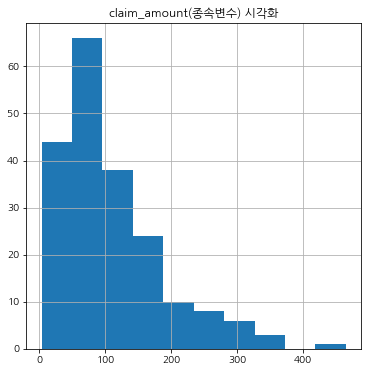

In [ ]:
## 종속변수 확인

plt.figure(figsize=(6,6))

plt.title("claim_amount(종속변수) 시각화")
plt.hist(df["claim_amount"])

plt.grid()
plt.show()

In [ ]:
### 데이터 분할 (train 160개, test 40개)
train = df.iloc[:160, :]
test = df.iloc[160:, :]

In [ ]:
### 감마회귀 모델 적합
from statsmodels.api import GLM, families

formula = "claim_amount ~ age + bmi + num_claims + C(smoking)"

model = GLM.from_formula(formula, data=train, family=families.Gamma()).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           claim_amount   No. Observations:                  160
Model:                            GLM   Df Residuals:                      155
Model Family:                   Gamma   Df Model:                            4
Link Function:          inverse_power   Scale:                         0.47363
Method:                          IRLS   Log-Likelihood:                -891.37
Date:                Sun, 24 Aug 2025   Deviance:                       87.844
Time:                        15:00:04   Pearson chi2:                     73.4
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1004
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0040      0.003      1.319      0.187      -0.002       0.010
C(smoking)[T.1]    -0.0003      0.001     -0.315      0.753      -0.002       0.002
age             -4.231e-05    3.2e-05     -1.324      0.186      -0.000    2.03e-05
bmi                 0.0003      0.000      3.173      0.002       0.000       0.001
num_claims         -0.0009      0.000     -2.953      0.003      -0.002      -0.000
===================================================================================
"""

In [ ]:
### 로그-우도 (모델 설명력)
model.llf

-891.3743792911043

In [ ]:
### 모델의 통계적 유의성 검정 (우도비 검정)
from scipy.stats import chi2

# H0 : 모든 회귀계수는 0이다.(=모델이 통계적으로 유의하지 않다.)
# H1 : 적어도 하나의 회귀계수는 0이 아니다.(=모델이 통계적으로 유의하다.)

# 우도비 검정통계량
s = model.null_deviance - model.deviance

# 우도비 검정통계량의 p-value
rv = chi2(loc=0, scale=1, df=model.df_model)

p = 1-rv.cdf(s)

print(f"우도비 검정통계량 : {s}")
print(f"우도비 검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

우도비 검정통계량 : 8.0148940420885
우도비 검정통계량의 p-value : 0.09103412775802122
귀무가설 채택


In [ ]:
### 회귀계수 통계적 유의성 검정
model.pvalues[1:]

C(smoking)[T.1]    0.753110
age                0.185643
bmi                0.001508
num_claims         0.003151
dtype: float64

In [ ]:
### 영향점 파악
df_cook = model.get_influence().summary_frame().copy()
df_cook.sort_values(by="standard_resid", ascending=False)

,dfb_Intercept,dfb_C(smoking)[T.1],dfb_age,dfb_bmi,dfb_num_claims,cooks_d,standard_resid,hat_diag,dffits_internal
23,-0.128717,-0.118453,-0.134275,0.258407,0.088582,0.035481,3.230159,0.016719,-0.421196
75,-0.015855,-0.160645,-0.000319,0.085273,-0.019362,0.016893,2.943094,0.009657,-0.290632
147,0.245262,-0.150025,-0.156847,-0.100723,-0.143917,0.024803,2.683022,0.016936,-0.352156
39,0.768915,-0.411904,0.250459,-0.868942,-0.115776,0.203868,2.445290,0.145646,-1.009625
91,-0.105870,-0.077086,-0.062297,0.219788,-0.121206,0.018035,2.411464,0.015270,-0.300292
...,...,...,...,...,...,...,...,...,...
31,0.010573,-0.115512,0.070511,-0.075686,0.114654,0.007411,-1.324275,0.020692,0.192497
114,0.018820,0.082668,-0.056499,-0.033533,0.061324,0.004757,-1.345385,0.012969,0.154218
22,0.036760,0.084115,-0.047344,-0.047742,0.004763,0.004560,-1.393199,0.011611,0.151003
73,0.089020,0.083084,-0.100732,-0.088986,0.061421,0.007764,-1.418701,0.018921,0.197023


In [ ]:
### 발생률 비율(IRR)

np.exp(model.params[1:])

C(smoking)[T.1]    0.999685
age                0.999958
bmi                1.000336
num_claims         0.999096
dtype: float64

In [ ]:
### 발생률 비율(IRR) 증가율

(np.exp(model.params[1:]) - 1)*100

C(smoking)[T.1]   -0.031510
age               -0.004231
bmi                0.033593
num_claims        -0.090414
dtype: float64

In [ ]:
print("""
bmi가 1단위 증가할 때 보험금 청구액이 약 0.0335% 증가한다.
age가 1단위 증가할 때 보험금 청구액이 약 -0.0042% 감소한다.
보험청구 횟수(num_claims)가 1단위 증가할 때 보험금 청구액이 약 -0.0904% 감소한다.
흡연을 하는 사람이면 보험금 청구액이 약 -0.0315% 감소한다.
""")


bmi가 1단위 증가할 때 보험금 청구액이 약 0.0335% 증가한다.
age가 1단위 증가할 때 보험금 청구액이 약 -0.0042% 감소한다.
보험청구 횟수(num_claims)가 1단위 증가할 때 보험금 청구액이 약 -0.0904% 감소한다.
흡연을 하는 사람이면 보험금 청구액이 약 -0.0315% 감소한다.



In [ ]:
## 예측

pred = model.predict(test)
pred

160     86.864602
161     83.153091
162    108.579689
163     96.743524
164    102.340446
165     75.826950
166    104.510957
167    107.893508
168    117.700919
169    113.897484
170     78.435976
171     83.516585
172     90.258149
173    100.942184
174     98.874432
175     93.725589
176    127.374970
177    144.513460
178    124.637421
179    100.744062
180    126.713161
181     86.030060
182    107.343162
183    101.450182
184    100.371336
185    153.925236
186     85.628354
187    113.236144
188    106.444685
189    111.689581
190     92.681667
191    101.538169
192     93.733338
193     87.830305
194    141.743395
195     74.264707
196     83.859960
197     74.417798
198     89.825655
199    134.529585
dtype: float64

In [ ]:
### 평가
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test["claim_amount"], pred)
rmse = np.sqrt(mse)

print(f"감마 회귀모델의 RMSE : {rmse}")

감마 회귀모델의 RMSE : 75.66099311756976


In [ ]:
df

,age,bmi,num_claims,smoking,claim_amount
0,65,18.3,2,1,124.23
1,22,28.0,0,0,92.32
2,48,30.6,2,1,75.65
3,54,28.3,1,0,117.06
4,58,31.2,1,0,102.83
...,...,...,...,...,...
195,29,31.8,0,0,31.95
196,37,36.3,3,0,136.65
197,23,31.9,0,1,230.07
198,31,27.8,1,0,67.92


In [ ]:
### 독립변수, 종속변수 나누기

y = df["claim_amount"]
X = df[["age", "bmi", "num_claims", "smoking"]]

In [ ]:
### 스케일링
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss_array = ss.fit_transform(X)
X_scaled = pd.DataFrame(ss_array,
                        columns=X.columns)
X_scaled

,age,bmi,num_claims,smoking
0,1.354364,-1.969740,0.299109,1.408927
1,-1.485112,0.255696,-1.254702,-0.709760
2,0.231780,0.852204,0.299109,1.408927
3,0.627986,0.324524,-0.477797,-0.709760
4,0.892124,0.989860,-0.477797,-0.709760
...,...,...,...,...
195,-1.022871,1.127516,-1.254702,-0.709760
196,-0.494597,2.159934,1.076014,-0.709760
197,-1.419077,1.150458,-1.254702,1.408927
198,-0.890803,0.209810,-0.477797,-0.709760


In [ ]:
### 데이터 분할
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(X_scaled, y,
                                                                      test_size=0.2,
                                                                      random_state=42)
print(train_input.shape, test_input.shape, train_target.shape, test_target.shape)

(160, 4) (40, 4) (160,) (40,)


In [ ]:
### sklearn에서 감마회귀 적합하기
from sklearn.linear_model import GammaRegressor
from sklearn.metrics import mean_absolute_error

gamma = GammaRegressor(alpha=0.7)          ### alpha = 규제
gamma.fit(train_input, train_target)
gamma_pred = gamma.predict(test_input)

mae = mean_absolute_error(test_target, gamma_pred)
mae

59.91203809929219